<a href="https://colab.research.google.com/github/enriquefroes/atletico-arena-mrv/blob/main/notebooks/01_panorama.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/analise_arena_mrv'
except ImportError:
    BASE = './analise_arena_mrv'

DADOS, GRAF, TAB = (os.path.join(BASE, p) for p in ['dados', 'graficos', 'tabelas'])
for p in (GRAF, TAB):
    os.makedirs(p, exist_ok=True)
if not os.path.exists(os.path.join(DADOS, 'jogos_arena_mrv.csv')):
    raise FileNotFoundError('Rode primeiro o notebook 00_dados.ipynb')
jogos = pd.read_csv(os.path.join(DADOS, 'jogos_arena_mrv.csv'), parse_dates=['data'])
jogos['mata_mata'] = jogos['fase'].str.contains('mata-mata')

PRETO, CINZA, VERDE, VERMELHO, AMARELO = '#111111', '#9ca3af', '#16a34a', '#dc2626', '#eab308'

def resumo(df, por=None):
    g = df.groupby(por) if por else df.groupby(lambda _: 'Total')
    r = g.agg(jogos=('pontos', 'size'), vitorias=('resultado', lambda s: (s == 'V').sum()),
              empates=('resultado', lambda s: (s == 'E').sum()), derrotas=('resultado', lambda s: (s == 'D').sum()),
              gols_pro=('gols_pro', 'sum'), gols_contra=('gols_contra', 'sum'), pontos=('pontos', 'sum'))
    r['aproveitamento'] = (r['pontos'] / (3 * r['jogos']) * 100).round(1)
    return r

def barras_vde(r, titulo, arquivo, ordenar=True):
    """Barras empilhadas de vitórias, empates e derrotas, com o aproveitamento ao lado."""
    t = r.sort_values('aproveitamento') if ordenar else r.iloc[::-1]
    fig, ax = plt.subplots(figsize=(11, max(3, 0.6 * len(t) + 1.5)))
    esq = np.zeros(len(t))
    for col, cor, nome in [('vitorias', VERDE, 'Vitórias'), ('empates', CINZA, 'Empates'), ('derrotas', VERMELHO, 'Derrotas')]:
        ax.barh(t.index.astype(str), t[col], left=esq, color=cor, label=nome)
        for i, (v, e) in enumerate(zip(t[col], esq)):
            if v > 0:
                ax.text(e + v / 2, i, int(v), ha='center', va='center', color='white', fontsize=9, fontweight='bold')
        esq += t[col].values
    for i, (tot, a) in enumerate(zip(t['jogos'], t['aproveitamento'])):
        ax.text(tot + 0.3, i, f'{a:.1f}%  ({tot} j)', va='center', fontsize=10, fontweight='bold')
    ax.set_xlim(0, t['jogos'].max() * 1.25)
    ax.set_xlabel('Jogos')
    ax.set_title(titulo, fontsize=12)
    ax.legend(loc='lower right', fontsize=9)
    salvar(arquivo)

def salvar(nome):
    plt.tight_layout()
    plt.savefig(os.path.join(GRAF, nome), dpi=150, bbox_inches='tight')
    plt.show()
    print('Salvo em', os.path.join(GRAF, nome))

Mounted at /content/drive


In [2]:
geral = resumo(jogos)
print(geral.to_string())
print(f"\nJogos sem perder: {(jogos.resultado != 'D').sum()} de {len(jogos)} ({(jogos.resultado != 'D').mean()*100:.1f}%)")
print(f"Gols por jogo: {jogos.gols_pro.mean():.2f} marcados · {jogos.gols_contra.mean():.2f} sofridos")
print(f"Jogos sem sofrer gol: {(jogos.gols_contra == 0).sum()}")

       jogos  vitorias  empates  derrotas  gols_pro  gols_contra  pontos  aproveitamento
Total     93        53       27        13       158           87     186            66.7

Jogos sem perder: 80 de 93 (86.0%)
Gols por jogo: 1.70 marcados · 0.94 sofridos
Jogos sem sofrer gol: 35


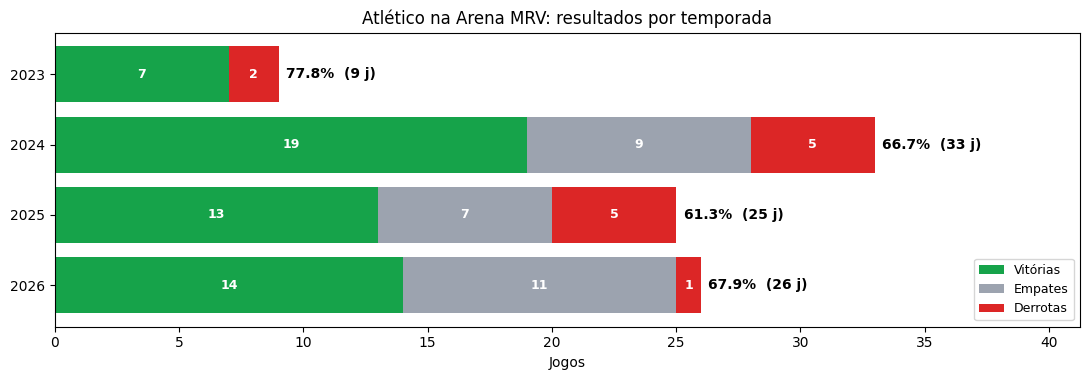

Salvo em /content/drive/MyDrive/analise_arena_mrv/graficos/01a_por_temporada.png


,jogos,vitorias,empates,derrotas,gols_pro,gols_contra,pontos,aproveitamento
temporada,,,,,,,,
2023,9,7,0,2,15,5,21,77.8
2024,33,19,9,5,59,31,66,66.7
2025,25,13,7,5,41,24,46,61.3
2026,26,14,11,1,43,27,53,67.9


In [3]:
temp = resumo(jogos, 'temporada')
temp.to_csv(os.path.join(TAB, '01_por_temporada.csv'))
barras_vde(temp, 'Atlético na Arena MRV: resultados por temporada', '01a_por_temporada.png', ordenar=False)
temp

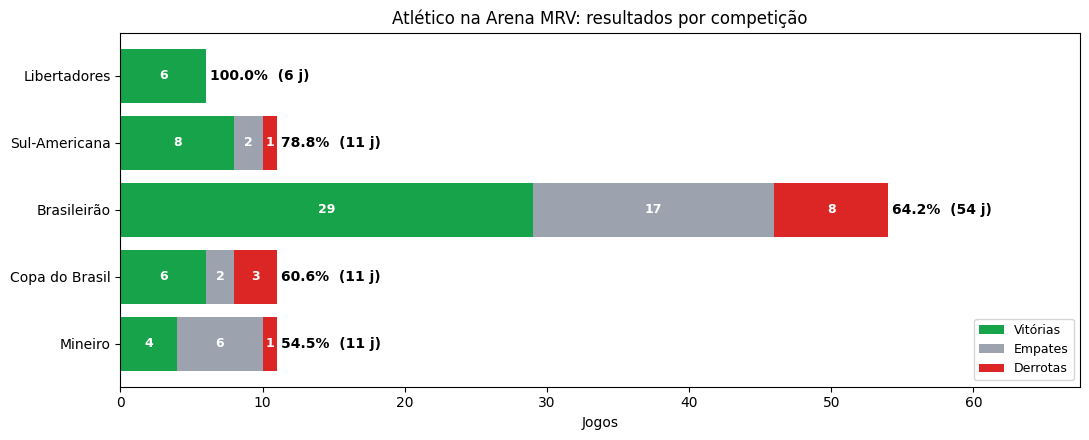

Salvo em /content/drive/MyDrive/analise_arena_mrv/graficos/01b_por_competicao.png


,jogos,vitorias,empates,derrotas,gols_pro,gols_contra,pontos,aproveitamento
competicao,,,,,,,,
Brasileirão,54,29,17,8,90,58,104,64.2
Copa do Brasil,11,6,2,3,15,7,20,60.6
Libertadores,6,6,0,0,15,3,18,100.0
Mineiro,11,4,6,1,17,9,18,54.5
Sul-Americana,11,8,2,1,21,10,26,78.8


In [4]:
comp = resumo(jogos, 'competicao')
comp.to_csv(os.path.join(TAB, '01_por_competicao.csv'))
barras_vde(comp, 'Atlético na Arena MRV: resultados por competição', '01b_por_competicao.png')
comp

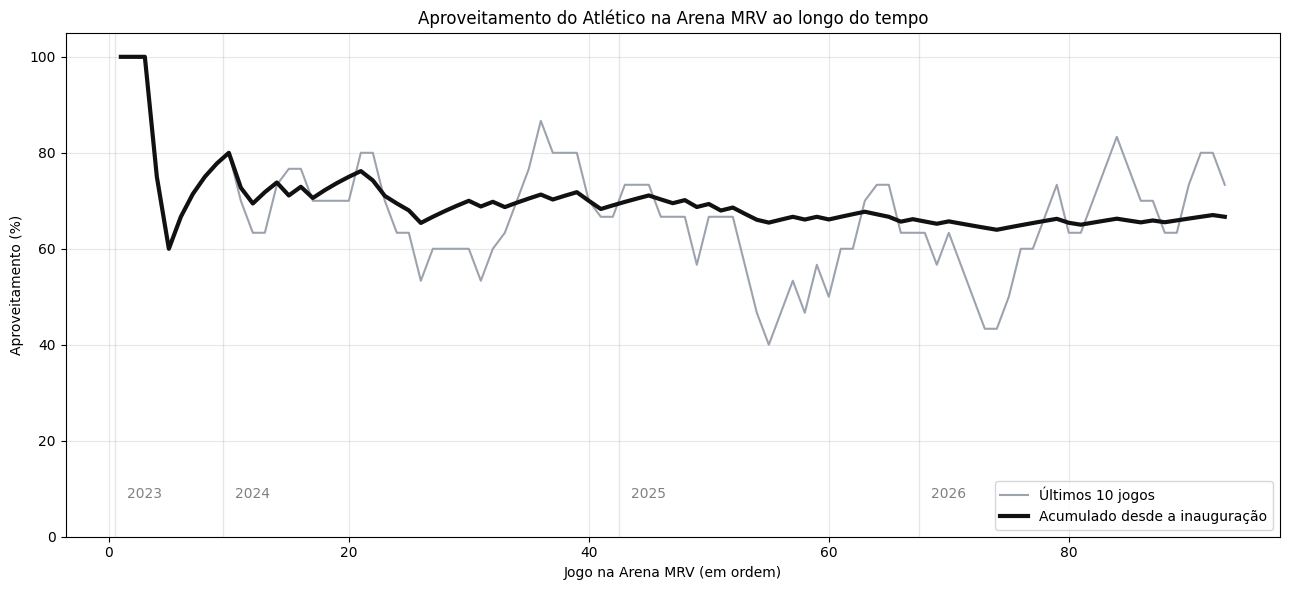

Salvo em /content/drive/MyDrive/analise_arena_mrv/graficos/01c_evolucao.png


In [5]:
j = jogos.sort_values('data').reset_index(drop=True)
j['aprov_acumulado'] = j['pontos'].cumsum() / (3 * (j.index + 1)) * 100
j['aprov_10'] = j['pontos'].rolling(10).mean() / 3 * 100
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(j.index + 1, j['aprov_10'], color=CINZA, lw=1.5, label='Últimos 10 jogos')
ax.plot(j.index + 1, j['aprov_acumulado'], color=PRETO, lw=3, label='Acumulado desde a inauguração')
for ano, g in j.groupby('temporada'):
    ax.axvline(g.index.min() + 0.5, color='#e5e7eb', lw=1, zorder=0)
    ax.text(g.index.min() + 1.5, 8, str(ano), fontsize=10, color='gray')
ax.set_ylim(0, 105)
ax.set_xlabel('Jogo na Arena MRV (em ordem)')
ax.set_ylabel('Aproveitamento (%)')
ax.set_title('Aproveitamento do Atlético na Arena MRV ao longo do tempo', fontsize=12)
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
salvar('01c_evolucao.png')

In [6]:
def maior_sequencia(cond):
    melhor, atual, ini, melhor_ini = 0, 0, None, None
    for i, c in enumerate(cond):
        if c:
            atual += 1
            ini = i if atual == 1 else ini
            if atual > melhor:
                melhor, melhor_ini = atual, ini
        else:
            atual = 0
    return melhor, melhor_ini

for nome, cond in [('Invencibilidade', j['resultado'] != 'D'), ('Vitórias seguidas', j['resultado'] == 'V')]:
    n, i = maior_sequencia(cond.tolist())
    print(f"{nome}: {n} jogos, de {j.loc[i, 'data']:%d/%m/%Y} a {j.loc[i + n - 1, 'data']:%d/%m/%Y}")
atual = 0
for r in j['resultado'][::-1]:
    if r == 'D': break
    atual += 1
n_rec, _ = maior_sequencia((j['resultado'] != 'D').tolist())
print(f"Invencibilidade atual: {atual} jogos" + (' (igualou o recorde!)' if atual == n_rec else ''))

Invencibilidade: 13 jogos, de 11/07/2024 a 22/10/2024
Vitórias seguidas: 5 jogos, de 28/10/2023 a 28/01/2024
Invencibilidade atual: 13 jogos (igualou o recorde!)


In [7]:
vit = jogos[jogos.resultado == 'V']
print((vit['gols_pro'].astype(str) + ' x ' + vit['gols_contra'].astype(str)).value_counts().head(8).to_string())

2 x 1    14
1 x 0    10
2 x 0     8
3 x 0     8
3 x 1     6
4 x 0     3
3 x 2     2
5 x 0     1
